In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    MeanShift
)
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold      import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from Transformers import *  
from prince import FAMD
import warnings
warnings.filterwarnings("ignore")
import pickle
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN  
import gower
from sklearn.manifold import TSNE


## Wczytanie danych

Wczytujemy dane po preprocessingu i przetwarzamy je ponownie przy pomocą FAMD lub odległości Gowera

In [15]:
df_train=pd.read_csv("data/TransformedData/train.csv")
df_test=pd.read_csv("data/TransformedData/test.csv") 

In [9]:
def load_famd(filepath: str):
    with open(filepath, 'rb') as f:
        famd = pickle.load(f)
    print(f"FAMD model loaded from {filepath!r}")
    return famd

In [16]:
Famd= load_famd("data/TransformedData/famd_model.pkl")
X_test= Famd.transform(df_test)
X_train= Famd.transform(df_train)

FAMD model loaded from 'data/TransformedData/famd_model.pkl'


In [ ]:
X_train_gower = gower.gower_matrix(df_train)
X_test_gower = gower.gower_matrix(df_test)

In [ ]:
df_raw_test = pd.read_csv("data/SplitRawData/test.csv")

## T-SNE plot function

funkcja przyjmuje dane, wykonuje na nich T-SNE i wizualizuje wyniki

In [31]:
def tsne_plot(
    X, 
    y, 
    title: str = "t-SNE",
    perplexity: float = 30.0,
    random_state: int = 42,
    point_size: int = 40,
    cmap: str = "tab10"
):
    
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state
    )
    X_emb = tsne.fit_transform(X)
    
   
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        X_emb[:, 0], X_emb[:, 1], 
        c=y, 
        cmap=cmap, 
        s=point_size, 
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2
    )
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    if title:
        plt.title(title)
    
   
    labels_unique = np.unique(y)

    handles = []
    for lab in labels_unique:
        handles.append(
            plt.Line2D(
                [], [], marker="o", ls="", 
                color=sc.cmap(sc.norm(lab)), 
                label=str(lab),
                markeredgecolor="k", 
                markersize=6
            )
        )
    plt.legend(
        handles=handles, 
        title="cluster", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()


## Algorytmy klasteryzacji dla ustalonych wcześniej parametrów (liczba klastrów / eps / bindwidth)

## KMeans Clustering - wraz z interpretacją

Train

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)
predicted_train = kmeans.predict(X_train)

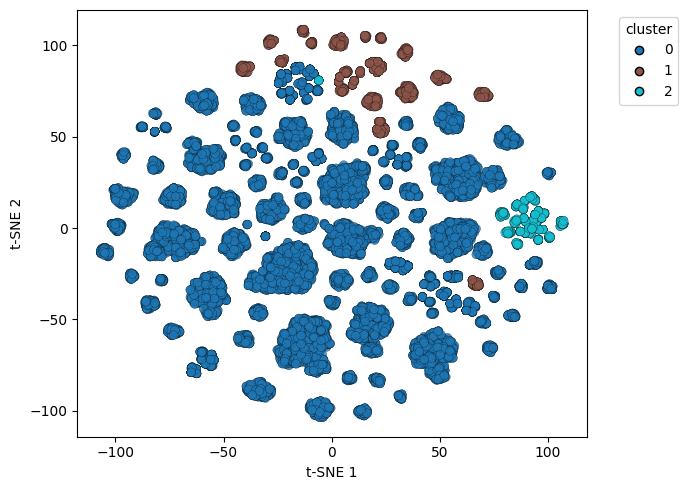

In [18]:
tsne_plot(X_train,y=predicted_train)

Test

In [45]:
predicted_test=kmeans.predict(X_test)

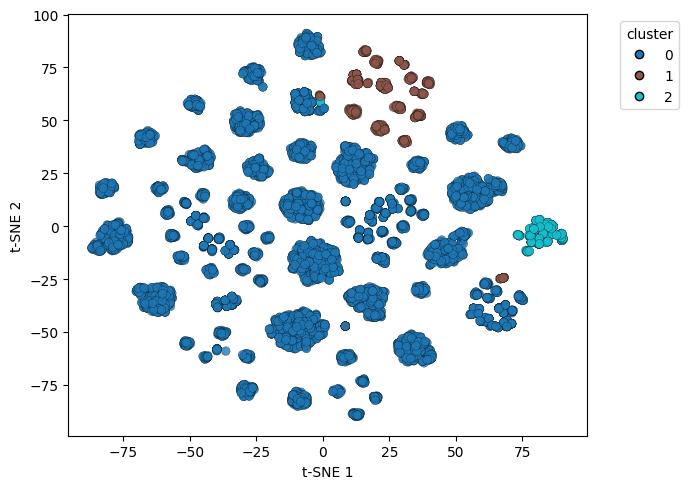

In [20]:
tsne_plot(X_test,y=predicted_test)

Z ciekawości zbadamy zależności kryjące się w tym podziale, jednak generalnie podział uznajemy za słaby

In [46]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_test, predicted_test)
feat_importances = pd.Series(rf.feature_importances_, index=df_test.columns).sort_values(ascending=False)

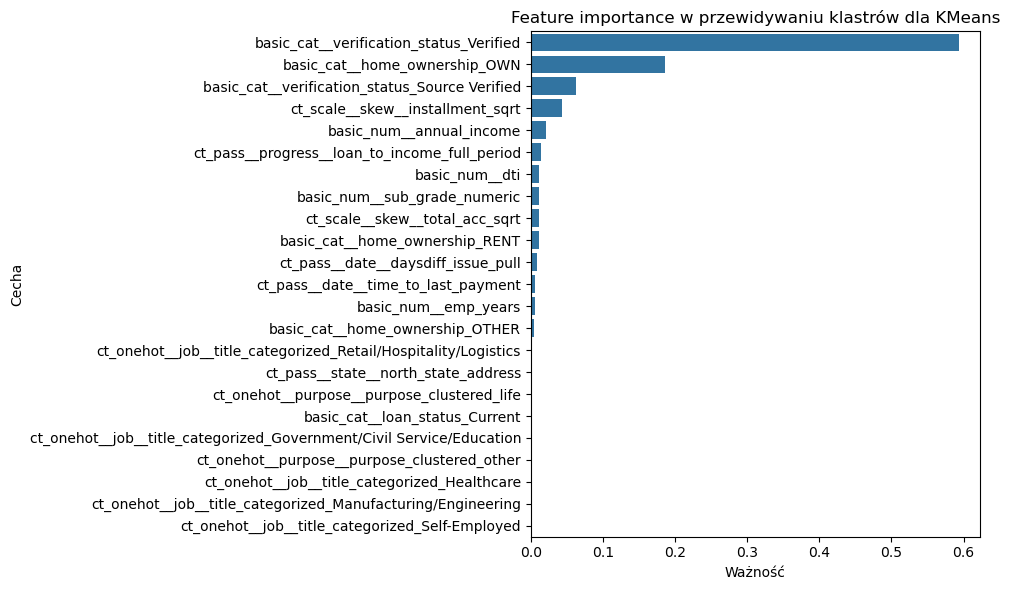

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature importance w przewidywaniu klastrów dla KMeans")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

In [87]:
KM_raw_labels = pd.concat([df_raw_test, pd.DataFrame(predicted_test)], axis=1).rename(columns={0: "cluster"})

In [88]:
numeric_cols = df_raw_test.select_dtypes(include=["float64", "int64"]).columns
numeric_cols

Index(['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount',
       'total_acc', 'total_payment', 'emp_years', 'grade_numeric',
       'sub_grade_numeric', 'issue_year', 'issue_month', 'issue_day',
       'issue_weekday', 'last_credit_pull_year', 'last_credit_pull_month',
       'last_credit_pull_day', 'last_credit_pull_weekday', 'last_payment_year',
       'last_payment_month', 'last_payment_day', 'last_payment_weekday',
       'next_payment_year', 'next_payment_month', 'next_payment_day',
       'next_payment_weekday', 'term_months'],
      dtype='object')

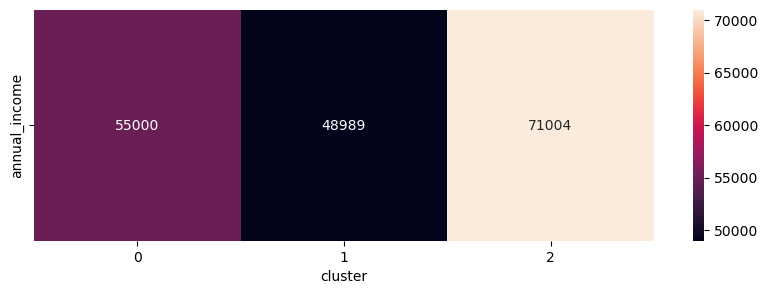

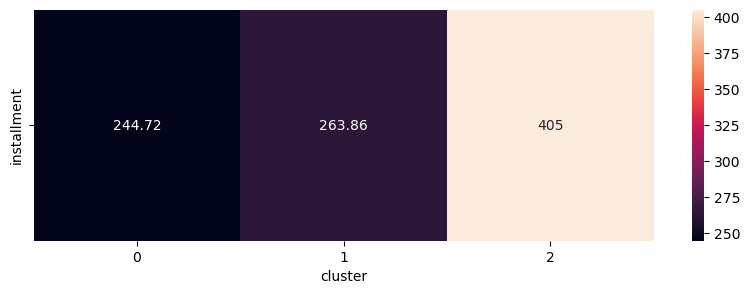

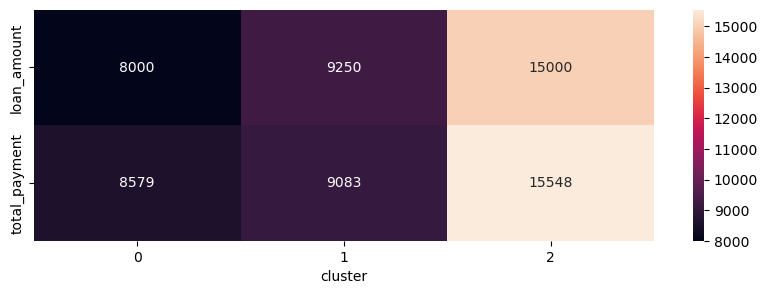

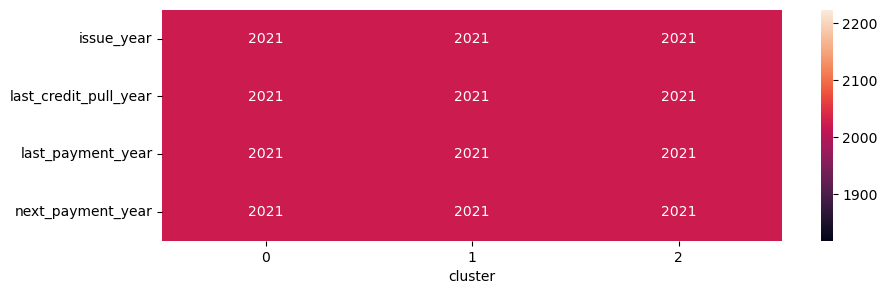

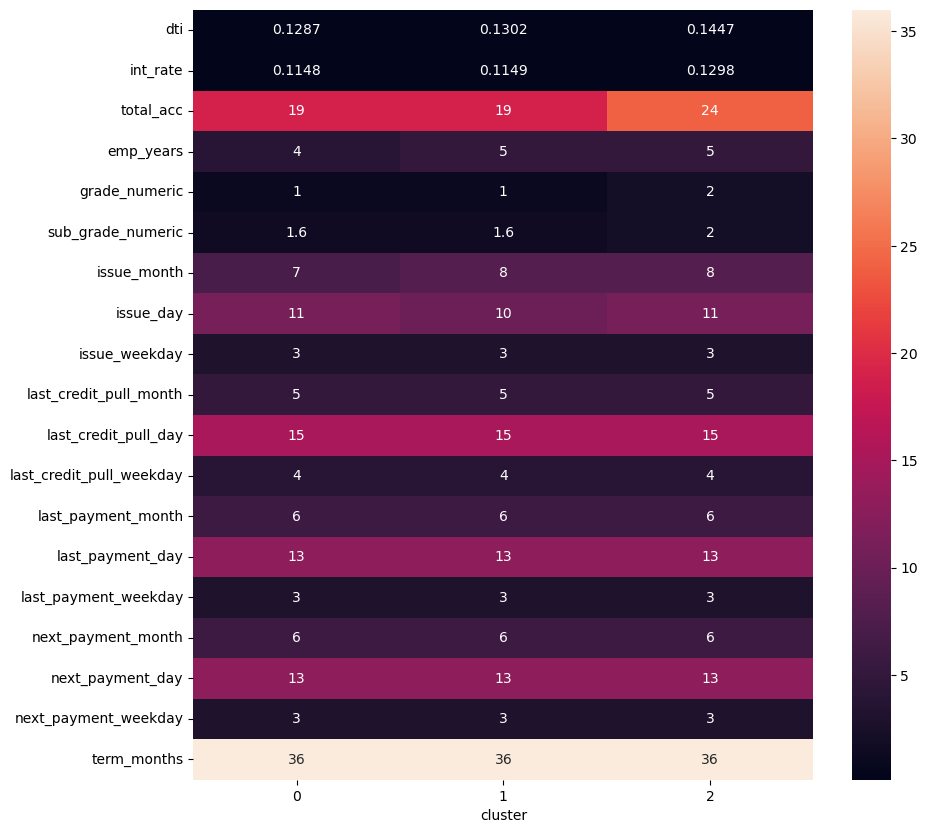

In [153]:
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['annual_income', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['installment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['loan_amount', 'total_payment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(KM_raw_labels[['issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,10))
sns.heatmap(KM_raw_labels.drop(columns=['annual_income', 'installment', 'loan_amount', 'total_payment', 'issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year']).groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()

In [109]:
cat_cols = ['home_ownership',
 'loan_status',
 'purpose',
 'verification_status']


Wystąpienia dla cechy: home_ownership


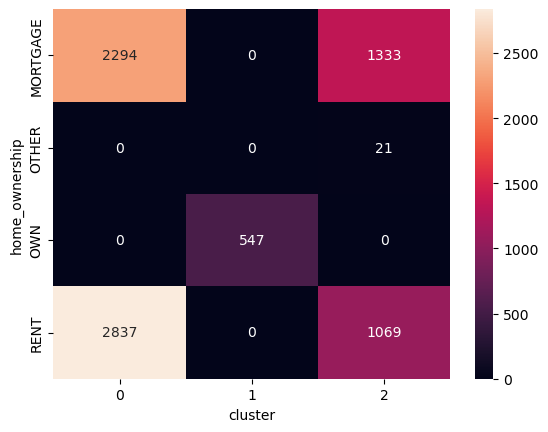


Wystąpienia dla cechy: loan_status


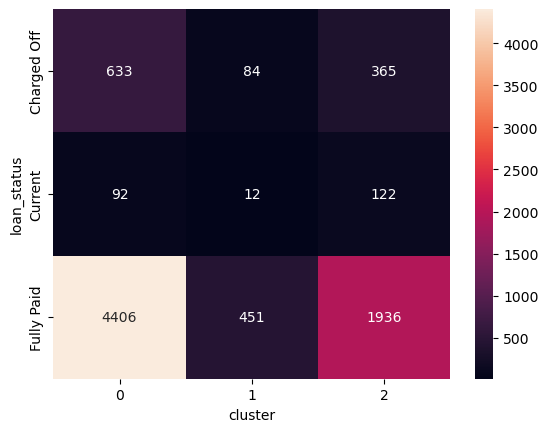


Wystąpienia dla cechy: purpose


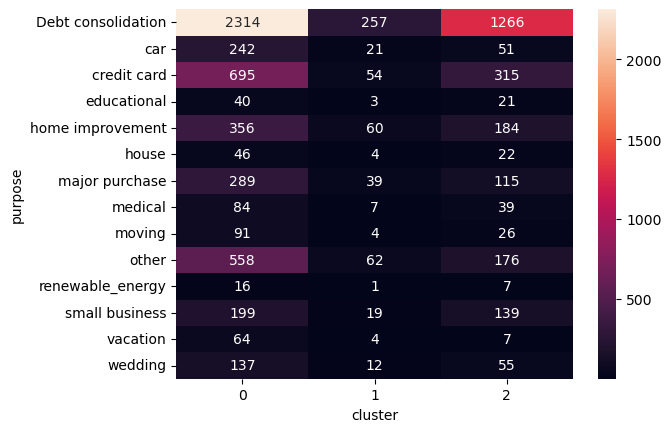


Wystąpienia dla cechy: verification_status


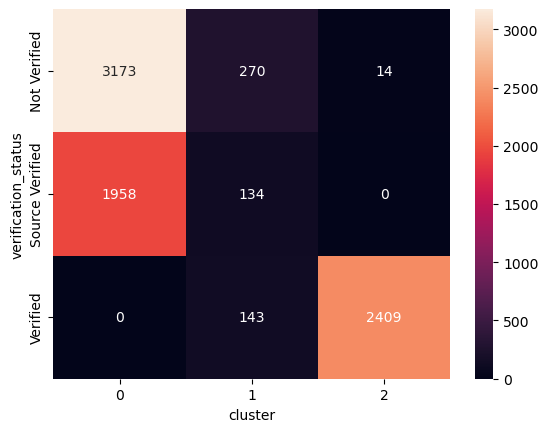

In [155]:
for col in cat_cols:
    print(f"\nWystąpienia dla cechy: {col}")
    crosstab = pd.crosstab(KM_raw_labels[col], KM_raw_labels['cluster'])
    sns.heatmap(crosstab, annot=True, fmt='g')
    plt.show()


## Mean shift

Train

In [ ]:
ms = MeanShift(bandwidth=15, n_jobs=-1)
ms.fit(X_train)
predicted_train = ms.labels_

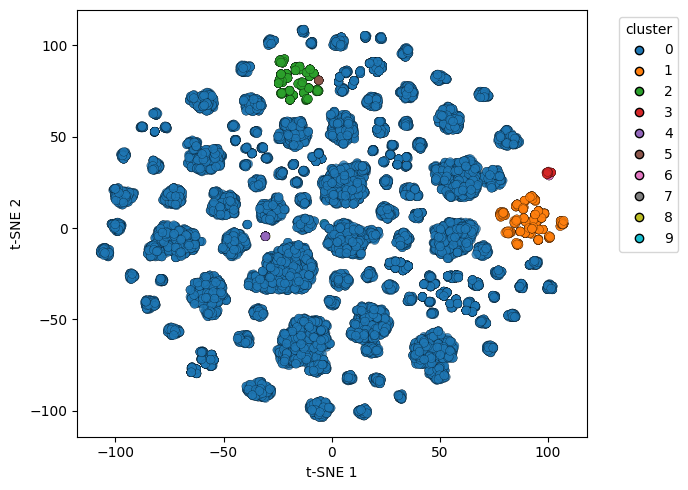

In [22]:
tsne_plot(X_train,y=predicted_train)

Test

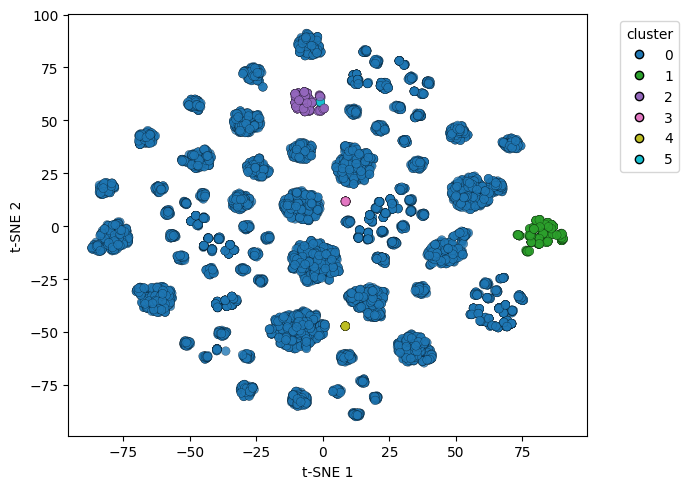

In [23]:
predicted_test = ms.predict(X_test)
tsne_plot(X_test,y=predicted_test)

Wyniki podobne co w KMeans, darujemy sobie dalszą analizę

## GMM - wraz z interpretacją

Train

In [17]:
gmm = GaussianMixture(n_components=10, random_state=42)
gmm.fit(X_train)
predicted_train = gmm.predict(X_train)


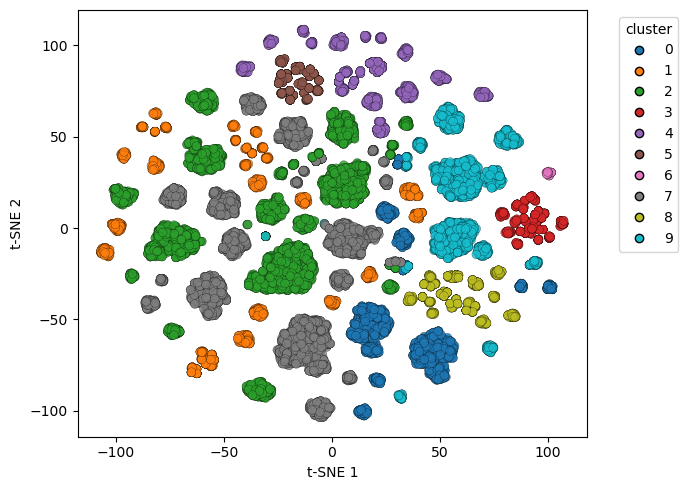

In [174]:
tsne_plot(X_train,y=predicted_train)

Test

In [18]:
predicted_test = gmm.predict(X_test)

In [19]:
with open("data/TransformedData/gmm_model.pkl", 'wb') as f:
    pickle.dump(gmm, f)

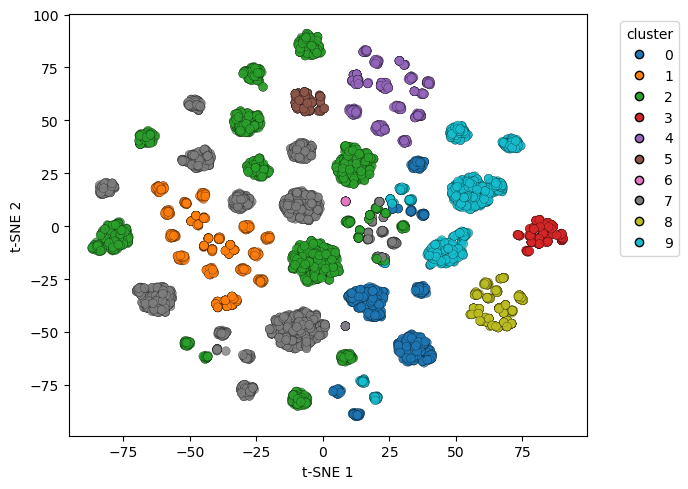

In [175]:
tsne_plot(X_test,y=predicted_test)

In [23]:
def inspect_gmm_parameters(gmm, feature_names=None):

    means = gmm.means_
    cov_type = gmm.covariance_type
    
    if cov_type == 'full':
        variances = np.array([np.diag(cov) for cov in gmm.covariances_])
    elif cov_type == 'tied':
        variances = np.tile(np.diag(gmm.covariances_), (gmm.n_components, 1))
    elif cov_type == 'diag':
        variances = gmm.covariances_
    elif cov_type == 'spherical':
        variances = np.tile(gmm.covariances_.reshape(-1,1), (1, gmm.means_.shape[1]))
    else:
        raise ValueError(f"Unknown covariance type: {cov_type}")

    n_components, n_features = means.shape
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(n_features)]
    index = [f"component_{i}" for i in range(n_components)]

    df_means = pd.DataFrame(means, index=index, columns=feature_names)
    df_vars  = pd.DataFrame(variances, index=index, columns=feature_names)
    return df_means, df_vars

In [ ]:
means_for_component, variances_for_component=inspect_gmm_parameters(gmm)
means_for_component

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20
component_0,-2.695900,-1.506075,-1.492261,0.181106,0.099994,-0.339978,-0.053874,0.196900,0.100240,-0.000434,...,-0.837706,-1.238496,0.466469,0.007684,0.127243,0.039362,0.030182,0.010356,0.002205,-0.011993
component_1,-1.265312,2.056602,-0.331840,0.683818,-0.076598,-0.419876,-0.042425,0.070919,-0.016845,0.437656,...,-0.379920,2.211302,1.317287,-0.098183,-0.089640,0.002374,-0.058798,-0.044083,-0.009350,0.008107
component_2,0.799449,6.448574,4.774039,-0.031783,0.509261,-0.674818,-1.990860,0.620516,0.304169,-1.391477,...,-1.793258,-3.976114,-0.816495,0.077071,0.131100,0.013318,0.040303,0.023831,0.004970,-0.021089
component_3,3.534853,-0.043346,-0.090549,3.159854,-8.679921,11.984591,-0.027770,-1.485157,-0.688697,1.085037,...,0.660765,-1.574504,1.084967,0.057569,-0.104843,-0.043910,0.236102,0.230491,0.055065,0.205355
component_4,2.153020,-0.849015,-1.934705,-1.726647,7.135162,4.884317,-7.083767,-1.166067,-0.285367,-0.755664,...,2.420815,0.358698,0.631559,0.016795,0.032513,0.045183,-0.005813,0.011204,0.037057,0.001798
component_5,4.475012,1.871627,5.643924,2.544052,17.567042,5.083263,14.388904,-16.113596,27.774103,36.597641,...,-1.225839,-5.163742,-1.057375,0.112034,0.199270,-0.080516,0.022553,-0.015485,-0.024620,0.002960
component_6,-1.590394,-3.508360,5.312115,-0.037052,0.633397,0.109588,0.072020,0.243148,0.305106,-0.951378,...,3.375914,1.196294,-0.950975,-0.153238,0.081919,-0.014346,0.007908,0.006083,0.001107,0.002459
component_7,0.785470,-0.106672,0.713616,-6.412903,-4.710143,-2.578294,0.261020,-2.385548,-1.080826,2.518309,...,1.978405,-0.551092,0.100043,-0.000105,-0.025671,0.006090,-0.027787,-0.006755,-0.019878,0.009892
component_8,-0.250687,3.166435,-0.901175,-1.905744,4.010290,4.271658,13.339247,2.532322,0.577267,-6.388986,...,2.292257,-0.990975,0.221222,-0.006734,-0.022698,0.002872,0.001846,0.010076,0.007184,-0.006855
component_9,3.545037,-0.889389,-1.114675,0.997725,0.095304,-1.148685,0.352946,0.388995,-0.210837,-0.087803,...,-0.664693,0.497005,-1.439391,0.112100,-0.097458,-0.072352,-0.009536,0.004880,-0.012714,-0.001071


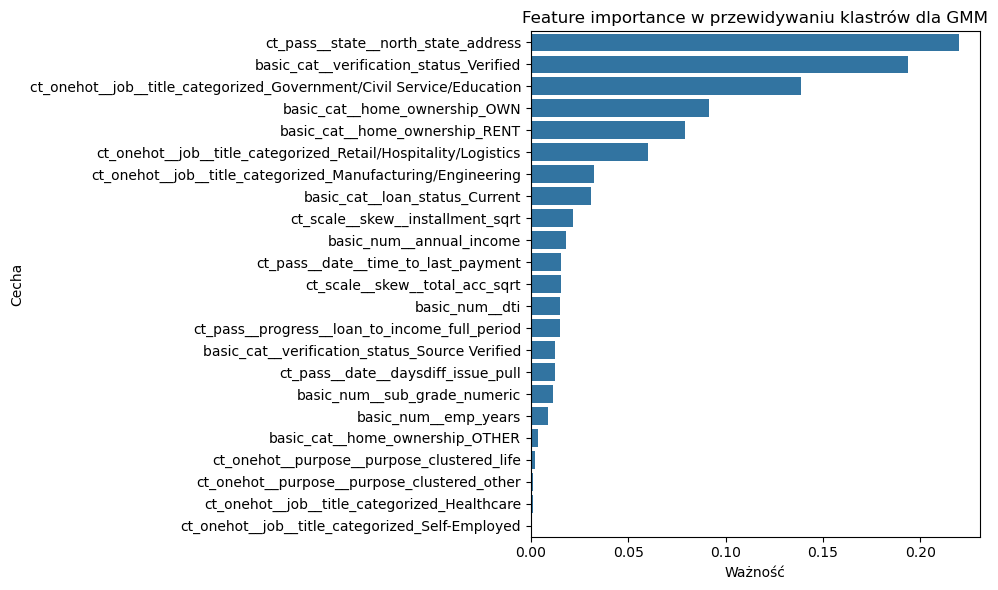

In [173]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_test, predicted_test)
feat_importances = pd.Series(rf.feature_importances_, index=df_test.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature importance w przewidywaniu klastrów dla GMM")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

In [125]:
GMM_raw_labels = pd.concat([df_raw_test, pd.DataFrame(predicted_test)], axis=1).rename(columns={0: "cluster"})

In [126]:
numeric_cols = df_raw_test.select_dtypes(include=["float64", "int64"]).columns
numeric_cols

Index(['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount',
       'total_acc', 'total_payment', 'emp_years', 'grade_numeric',
       'sub_grade_numeric', 'issue_year', 'issue_month', 'issue_day',
       'issue_weekday', 'last_credit_pull_year', 'last_credit_pull_month',
       'last_credit_pull_day', 'last_credit_pull_weekday', 'last_payment_year',
       'last_payment_month', 'last_payment_day', 'last_payment_weekday',
       'next_payment_year', 'next_payment_month', 'next_payment_day',
       'next_payment_weekday', 'term_months'],
      dtype='object')

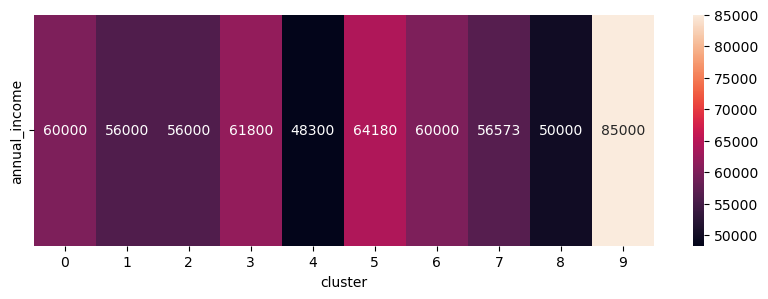

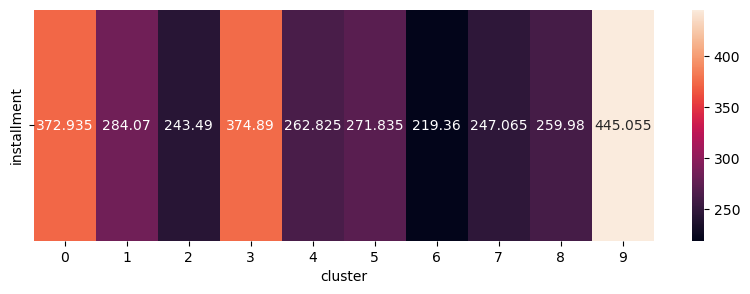

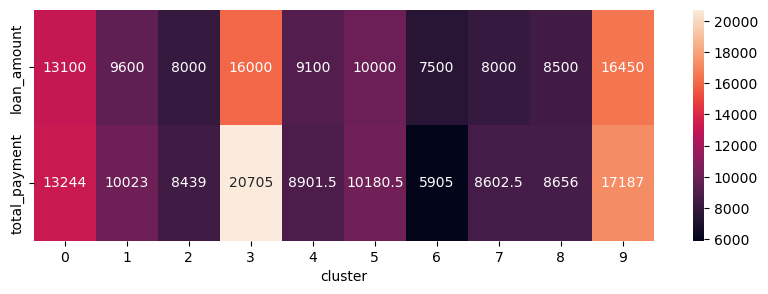

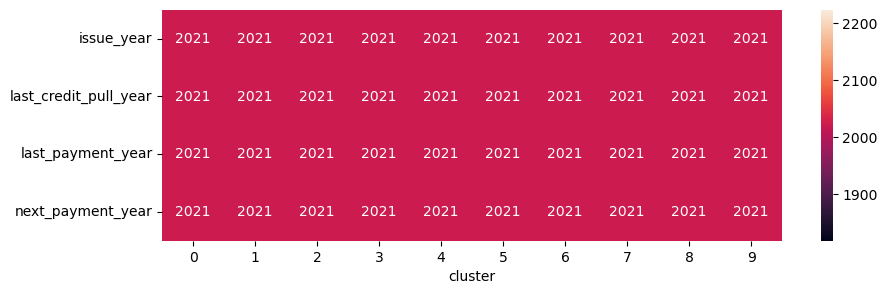

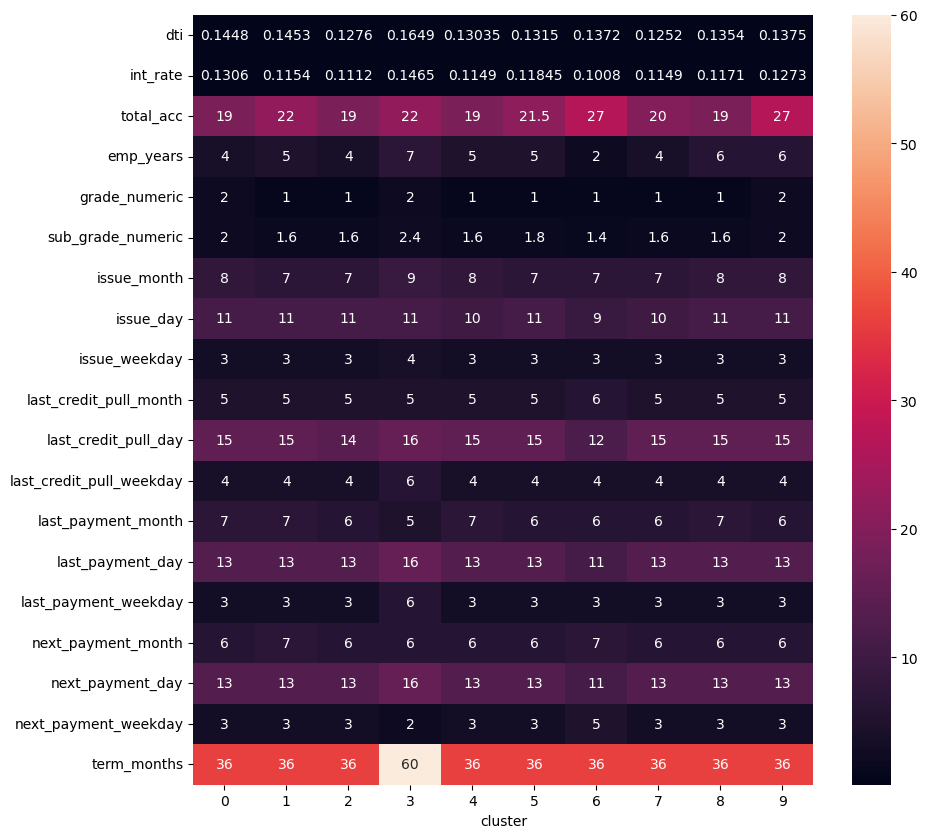

In [152]:
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['annual_income', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['installment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['loan_amount', 'total_payment', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,3))
sns.heatmap(GMM_raw_labels[['issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year', 'cluster']].groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()
plt.figure(figsize=(10,10))
sns.heatmap(GMM_raw_labels.drop(columns=['annual_income', 'installment', 'loan_amount', 'total_payment', 'issue_year', 'last_credit_pull_year', 'last_payment_year', 'next_payment_year']).groupby('cluster').median(numeric_only=True).T, annot=True, fmt='g')
plt.show()

In [135]:
cat_cols = ['home_ownership',
 'loan_status',
 'purpose',
 'verification_status']


Wystąpienia dla cechy: home_ownership


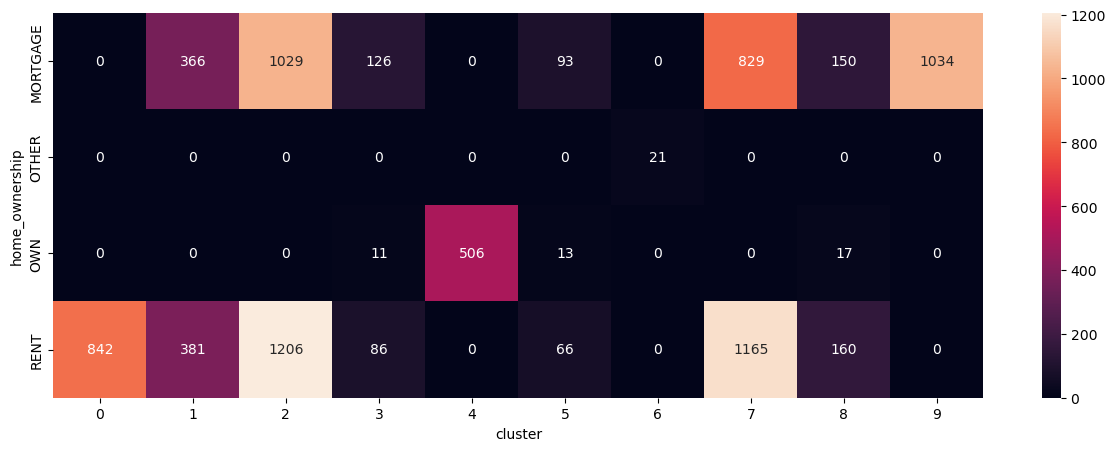


Wystąpienia dla cechy: loan_status


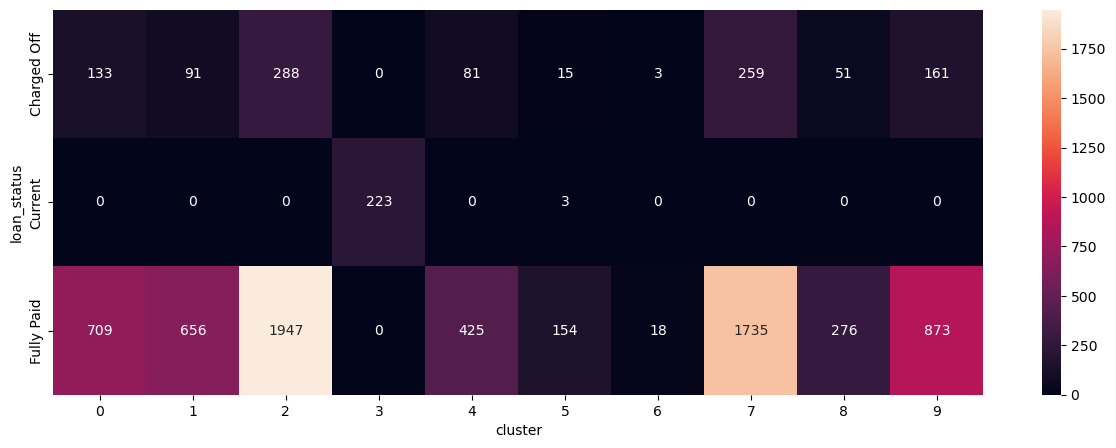


Wystąpienia dla cechy: purpose


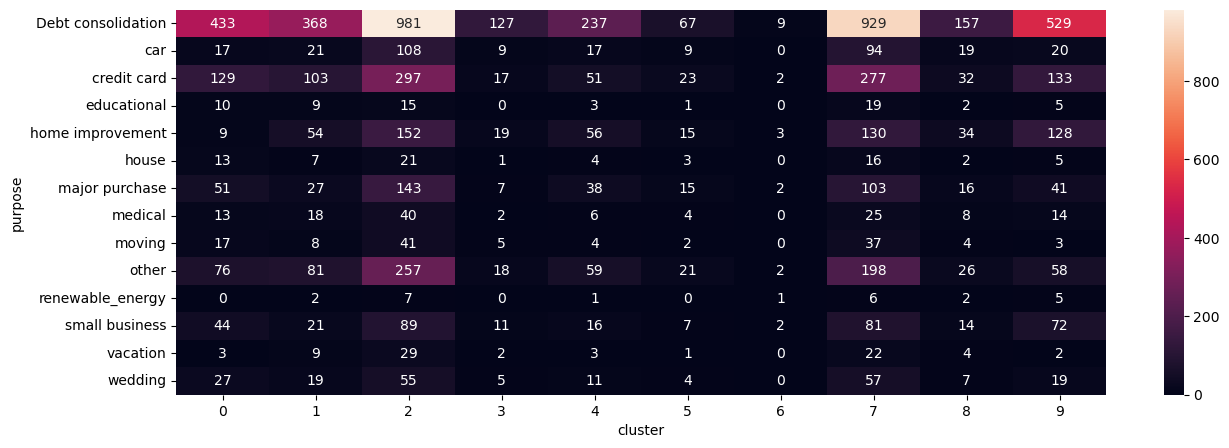


Wystąpienia dla cechy: verification_status


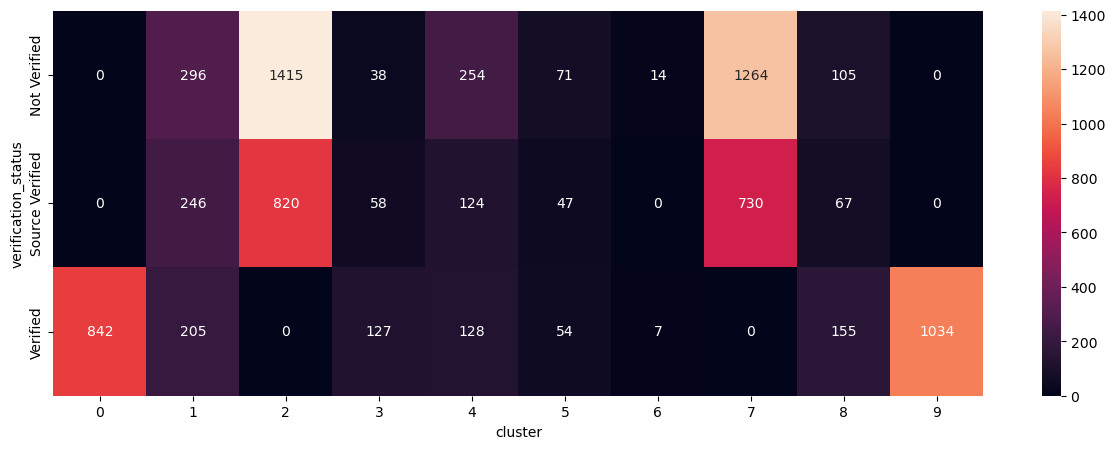

In [140]:
for col in cat_cols:
    print(f"\nWystąpienia dla cechy: {col}")
    crosstab = pd.crosstab(GMM_raw_labels[col], GMM_raw_labels['cluster'])
    plt.figure(figsize=(15,5))
    sns.heatmap(crosstab, annot=True, fmt='g')
    plt.show()


In [161]:
transf_with_labels = pd.concat([df_test, pd.Series(predicted_test)], axis=1).rename(columns={0: "cluster"})

In [162]:
transf_with_labels.columns

Index(['ct_onehot__job__title_categorized_Government/Civil Service/Education',
       'ct_onehot__job__title_categorized_Healthcare',
       'ct_onehot__job__title_categorized_Manufacturing/Engineering',
       'ct_onehot__job__title_categorized_Retail/Hospitality/Logistics',
       'ct_onehot__job__title_categorized_Self-Employed',
       'ct_onehot__purpose__purpose_clustered_life',
       'ct_onehot__purpose__purpose_clustered_other',
       'ct_scale__skew__installment_sqrt', 'ct_scale__skew__total_acc_sqrt',
       'ct_pass__date__time_to_last_payment',
       'ct_pass__date__daysdiff_issue_pull',
       'ct_pass__state__north_state_address',
       'ct_pass__progress__loan_to_income_full_period', 'basic_num__dti',
       'basic_num__annual_income', 'basic_num__emp_years',
       'basic_num__sub_grade_numeric', 'basic_cat__home_ownership_OTHER',
       'basic_cat__home_ownership_OWN', 'basic_cat__home_ownership_RENT',
       'basic_cat__loan_status_Current',
       'basic_cat__ver

<Axes: xlabel='cluster'>

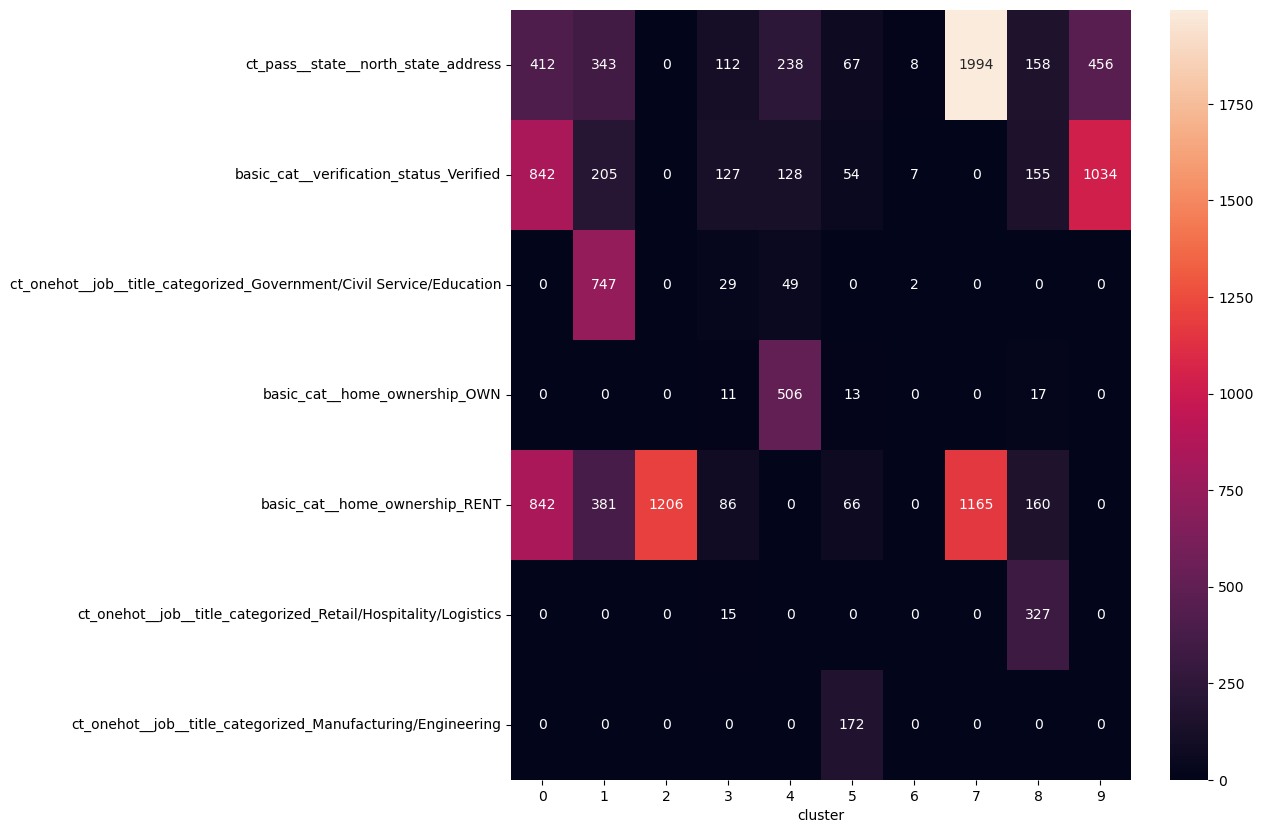

In [168]:
plt.figure(figsize=(10,10))
sns.heatmap(transf_with_labels[['ct_pass__state__north_state_address', 'basic_cat__verification_status_Verified',
                                'ct_onehot__job__title_categorized_Government/Civil Service/Education', 'basic_cat__home_ownership_OWN',
                                'basic_cat__home_ownership_RENT', 'ct_onehot__job__title_categorized_Retail/Hospitality/Logistics',
                                'ct_onehot__job__title_categorized_Manufacturing/Engineering', 'cluster']].groupby('cluster').sum().T, annot=True, fmt='g')

## Agglomerative

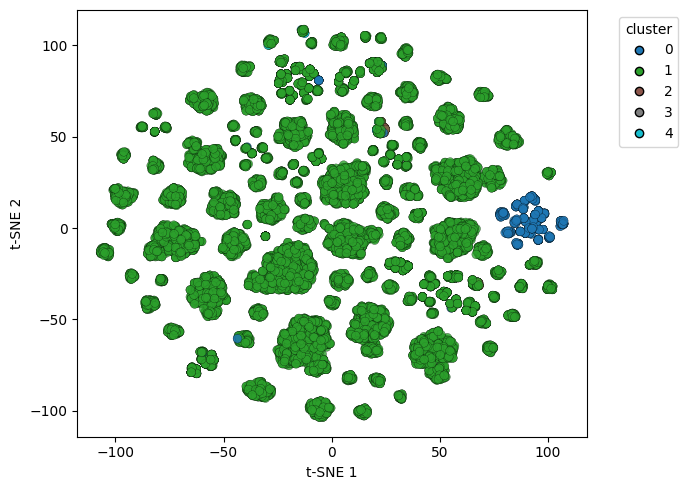

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=5,
    linkage='average',
    metric='precomputed'  
)
y_train = agg.fit_predict(X_train_gower)
tsne_plot(X_train, y=y_train)

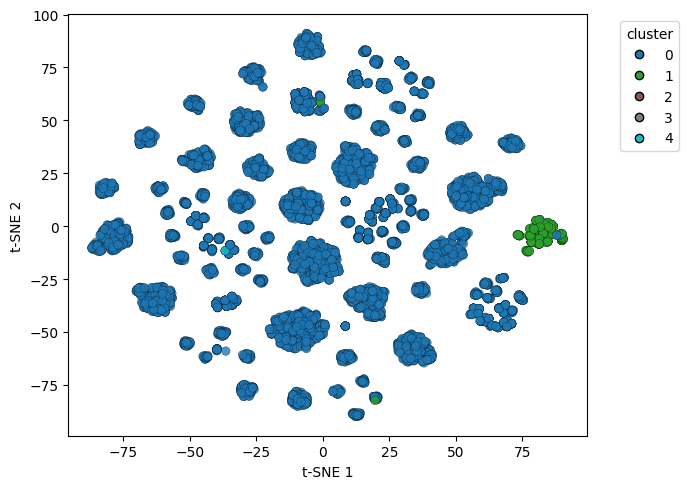

In [28]:
agg_test = AgglomerativeClustering(
    n_clusters=5,
    linkage='average',
    metric='precomputed'
)
y_test = agg_test.fit_predict(X_test_gower)
tsne_plot(X_test, y=y_test)


Wyniki nawet gorsze niż KMeans, darujemy sobie dalszą analizę

## DBScan

Train

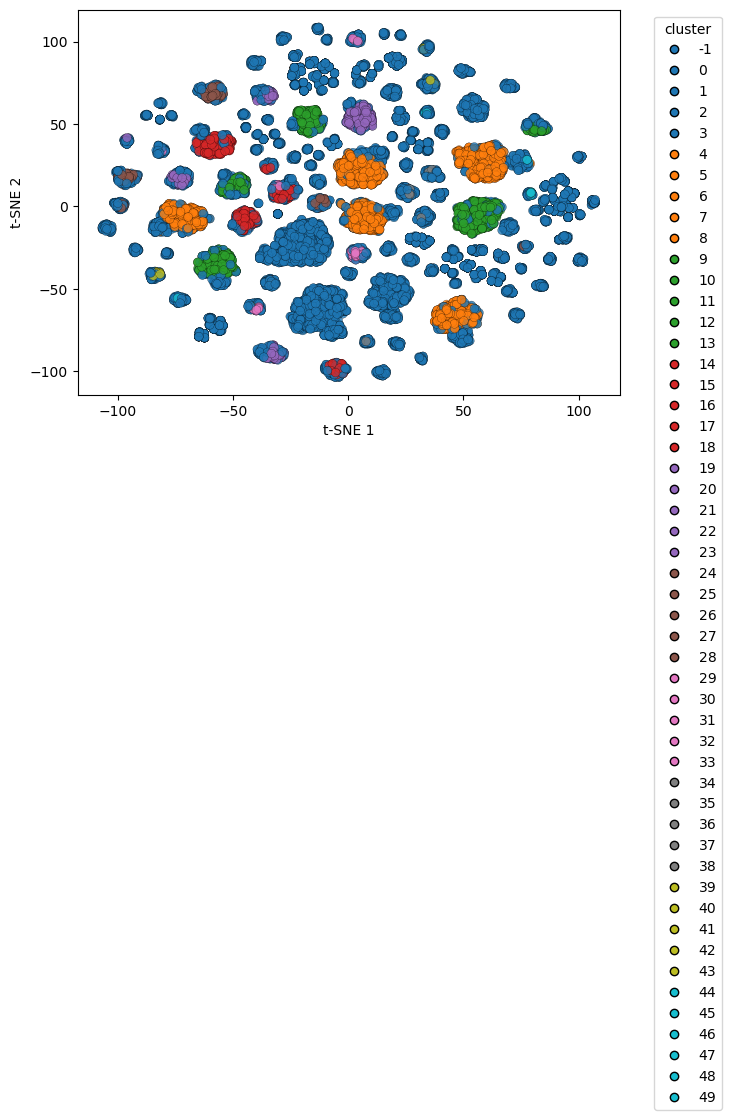

In [36]:
params={'eps': 0.03, 'min_samples': 10, 'metric' : 'precomputed'}

dbscan = DBSCAN(**params) 
predicted_train=dbscan.fit_predict(X_train_gower)

tsne_plot(X_train, y=predicted_train)


Test

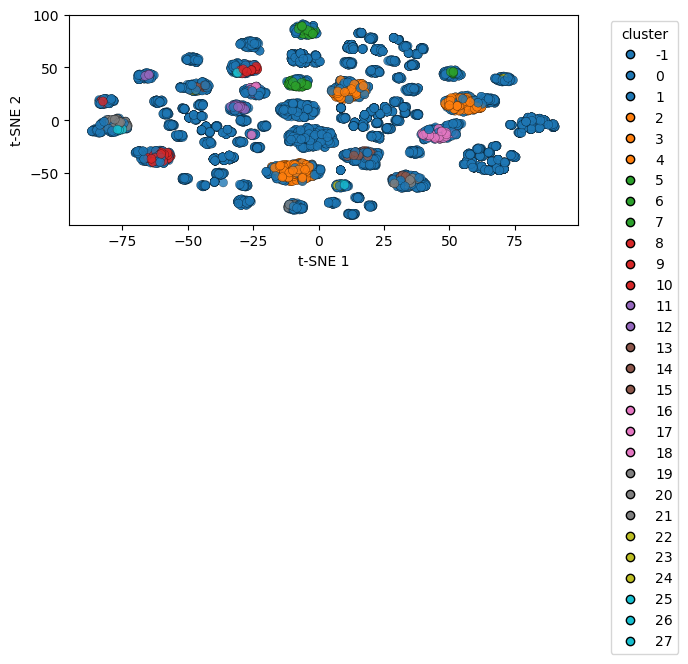

In [37]:
predicted_test = dbscan.fit_predict(X_test_gower)
tsne_plot(X_test, y=predicted_test)

Wyniki bardzo dziwne, darujemy sobie interpretację

## Dla walidacji


In [27]:
def loadGMM(filepath: str):
    with open(filepath, 'rb') as f:
        gmm = pickle.load(f)
    print(f"GMM model loaded from {filepath!r}")
    return gmm

In [29]:
df_validation=pd.read_csv("data/TransformedData/val.csv")
Famd=load_famd("data/TransformedData/famd_model.pkl")
gmm= loadGMM("data/TransformedData/gmm_model.pkl")
X_val=Famd.transform(df_validation)
predicted_validation = gmm.predict(X_val)

FAMD model loaded from 'data/TransformedData/famd_model.pkl'
GMM model loaded from 'data/TransformedData/gmm_model.pkl'


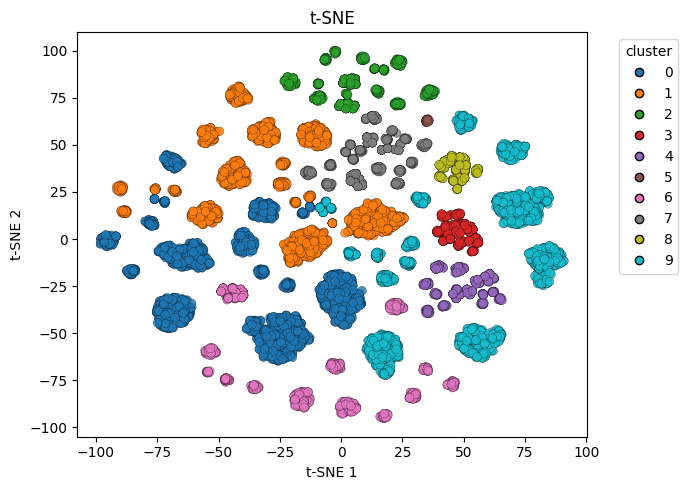

In [32]:
tsne_plot(X_val,predicted_validation)